# D_S3_polyfit — Polynomial Fitting for Line Detection & Curvature Classification

Replace segment-based slope analysis with **global polynomial fitting** in the decision tree.

**Replaces Step 5 (Line Detection)**: polyfit `'linear'` → Line (instead of slope SD < 0.1)
**Replaces Step 6 (Curvature Type)**: directly classify from f′(x) and f″(x) — no V_s gate, no "uncertain" layer.

---

**Method**: Fit **cubic polynomial** (degree 3), classify from derivative patterns:

| f′ pattern | f″ dominance | Shape |
|---|---|---|
| f″ negligible vs f′ | — | **linear** (→ Line) |
| monotonic (no sign change) | ≥ 75% one side | **convex** or **concave** |
| monotonic | < 75% (balanced) | **inflected** |
| 1 sign change | positive dominant | **U-shape** |
| 1 sign change | negative dominant | **inverted-U** |
| ≥ 2 sign changes | any | **complex** → logistic fallback |

In [25]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit
import warnings, os, time

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

S1_DIR = Path('output/S1')
OUT_DIR = Path('output/S3_polyfit')
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Data & Ground Truth

In [26]:
cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
pts = np.load(S1_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']

cases['snr_float'] = cases['snr'].apply(lambda x: float(x))
case_idx_map = pd.Series(np.arange(len(cases)), index=cases['case_id']).to_dict()

TARGET_FIDS = [f'F{i:02d}' for i in range(1, 19)] + ['F21']

# Ground truth: polyfit shape label
GROUND_TRUTH = {
    'F01': 'linear',    'F02': 'linear',
    'F03': 'convex',    'F04': 'concave',
    'F05': 'concave',   'F06': 'convex',
    'F07': 'concave',   'F08': 'convex',
    'F09': 'concave',   'F10': 'convex',
    'F11': 'convex',    'F12': 'concave',
    'F13': 'inflected', 'F14': 'inflected',
    'F15': 'inflected', 'F16': 'inflected',
    'F17': 'inverted-U','F18': 'U-shape',
    'F21': 'complex',
}

# How polyfit maps to decision tree steps
# Step 5: 'linear' → Line
# Step 6: everything else → Curvature Type (no uncertain)
TREE_STEP5 = {k: ('Line' if v == 'linear' else 'Non-Line') for k, v in GROUND_TRUTH.items()}
TREE_STEP6 = {k: v for k, v in GROUND_TRUTH.items() if v != 'linear'}

SHORT = {}
for fid in TARGET_FIDS:
    row = cases[cases['family_id'] == fid].iloc[0]
    SHORT[fid] = str(row['family_name'])

target_cases = cases[cases['family_id'].isin(TARGET_FIDS)].copy()
print(f'Target families: {len(TARGET_FIDS)}')
print(f'Target cases:    {len(target_cases):,}')
print()

gt_table = pd.DataFrame({
    'family': [SHORT[f] for f in TARGET_FIDS],
    'polyfit_shape': [GROUND_TRUTH[f] for f in TARGET_FIDS],
    'step5_line': [TREE_STEP5[f] for f in TARGET_FIDS],
    'step6_curvature': [TREE_STEP6.get(f, '—') for f in TARGET_FIDS],
}, index=TARGET_FIDS)
gt_table.index.name = 'family_id'
display(gt_table)

Target families: 19
Target cases:    114,570



,family,polyfit_shape,step5_line,step6_curvature
family_id,,,,
F01,Linear positive,linear,Line,—
F02,Linear negative,linear,Line,—
F03,Power convex positive,convex,Non-Line,convex
F04,Power convex negative,concave,Non-Line,concave
F05,Power concave positive,concave,Non-Line,concave
F06,Power concave negative,convex,Non-Line,convex
F07,Saturation positive,concave,Non-Line,concave
F08,Saturation negative,convex,Non-Line,convex
F09,Log positive,concave,Non-Line,concave


## 2. Polynomial Fitting & Classification

Fit **cubic polynomial** (degree 3), classify from f′(x) and f″(x) patterns.

**Tree integration**:
- **Step 5 (Line Detection)**: polyfit shape == `'linear'` → **Line**
- **Step 6 (Curvature Type)**: polyfit shape directly → `convex / concave / inflected / U-shape / inverted-U / complex`
  - No V_s gate, no "uncertain" layer — every non-line case gets a curvature label

In [27]:
# ── Configuration ──
INTERIOR_MARGIN = 0.10   # exclude outer 10% on each side
N_GRID = 200             # dense grid points for derivative evaluation
DOMINANCE_THRESH = 0.75  # weighted f'' dominance threshold for convex/concave vs inflected
LOGISTIC_R2_THRESH = 0.85  # R² threshold for logistic fallback


# ── Logistic fallback ──

def _safe_logistic(x, L, k, x0, b):
    z = np.clip(-k * (x - x0), -500, 500)
    return L / (1.0 + np.exp(z)) + b


def _fit_logistic(xs, ys):
    n = len(xs)
    x_range = xs[-1] - xs[0]
    n10 = max(1, n // 10)
    y_lo = np.mean(ys[:n10])
    y_hi = np.mean(ys[-n10:])
    L0 = y_hi - y_lo
    b0 = y_lo
    x0_0 = np.median(xs)

    best_rss = np.inf
    best_popt = None

    for k_scale in [3, 10, 40]:
        k0 = k_scale / (x_range + 1e-10)
        try:
            popt, _ = curve_fit(
                _safe_logistic, xs, ys,
                p0=[L0, k0, x0_0, b0],
                maxfev=2000,
            )
            pred = _safe_logistic(xs, *popt)
            rss = np.sum((ys - pred) ** 2)
            if rss < best_rss:
                best_rss = rss
                best_popt = popt
        except Exception:
            pass

    return best_popt, best_rss


# ── Main classifier ──

def polyfit_classify(x, y):
    """Fit cubic polynomial and classify shape from derivatives.
    Falls back to logistic fit when cubic says 'complex'."""
    order = np.argsort(x)
    xs = x[order].astype(np.float64)
    ys = y[order].astype(np.float64)

    ss_tot = np.sum((ys - ys.mean()) ** 2)
    r2 = {}
    for deg in [1, 2, 3]:
        c = np.polyfit(xs, ys, deg)
        pred = np.polyval(c, xs)
        ss_res = np.sum((ys - pred) ** 2)
        r2[deg] = 1.0 - ss_res / ss_tot if ss_tot > 1e-30 else 0.0

    coeffs3 = np.polyfit(xs, ys, 3)
    p = np.poly1d(coeffs3)

    x_lo = xs[0]  + INTERIOR_MARGIN * (xs[-1] - xs[0])
    x_hi = xs[-1] - INTERIOR_MARGIN * (xs[-1] - xs[0])
    x_grid = np.linspace(x_lo, x_hi, N_GRID)

    p1 = np.polyder(p, 1)
    p2 = np.polyder(p, 2)
    f1 = p1(x_grid)
    f2 = p2(x_grid)

    shape = _classify_derivatives(f1, f2)

    # ── Logistic fallback for "complex" ──
    logistic_used = False
    if shape == 'complex':
        popt, rss_log = _fit_logistic(xs, ys)
        if popt is not None:
            r2_log = 1.0 - rss_log / ss_tot if ss_tot > 1e-30 else 0.0
            x0_fit = popt[2]
            if r2_log > LOGISTIC_R2_THRESH and x_lo <= x0_fit <= x_hi:
                shape = 'inflected'
                logistic_used = True

    mean_f1 = np.mean(f1)
    if np.max(np.abs(f1)) < 1e-10:
        direction = 'none'
    elif mean_f1 > 0:
        direction = 'positive'
    else:
        direction = 'negative'

    return {
        'shape': shape, 'direction': direction,
        'r2_1': r2[1], 'r2_2': r2[2], 'r2_3': r2[3],
        'logistic_used': logistic_used,
        'x_grid': x_grid,
        'f_grid': p(x_grid), 'f1_grid': f1, 'f2_grid': f2,
    }


def _curvature_dominance(f2):
    abs_f2 = np.abs(f2)
    total = np.sum(abs_f2)
    if total < 1e-10:
        return 1.0, 0
    frac_pos = np.sum(abs_f2[f2 > 0]) / total
    frac_neg = 1.0 - frac_pos
    if frac_pos >= frac_neg:
        return frac_pos, 1
    else:
        return frac_neg, -1


def _classify_derivatives(f1, f2):
    max_f1 = np.max(np.abs(f1))
    max_f2 = np.max(np.abs(f2))

    if max_f2 < 0.05 * max_f1 and max_f1 > 1e-10:
        return 'linear'

    n_f1_changes = _count_sign_changes(f1)
    dominance, dom_sign = _curvature_dominance(f2)

    if n_f1_changes == 0:
        if dominance >= DOMINANCE_THRESH:
            return 'convex' if dom_sign > 0 else 'concave'
        else:
            return 'inflected'

    if n_f1_changes == 1:
        return 'U-shape' if dom_sign > 0 else 'inverted-U'

    return 'complex'


def _count_sign_changes(values):
    signs = np.sign(values).copy()
    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]
    n = 0
    for i in range(1, len(signs)):
        if signs[i] != signs[i - 1] and signs[i] != 0 and signs[i - 1] != 0:
            n += 1
    return n


print('Classification functions defined (with curvature dominance + logistic fallback).')

Classification functions defined (with curvature dominance + logistic fallback).


## 3. Validation on Low-Noise Data (SNR = 500)

Run polyfit on all target families at SNR ≈ 500, then evaluate:
- **Step 5 accuracy**: is `'linear'` correctly separating Line vs Non-Line?
- **Step 6 accuracy**: are curvature types correct for non-line cases?

In [28]:
# Find the SNR level closest to 500
finite_snrs = cases[np.isfinite(cases['snr_float'])]['snr_float'].unique()
VAL_SNR = finite_snrs[np.argmin(np.abs(finite_snrs - 500))]
print(f'Validation SNR: {VAL_SNR}')

val_cases = target_cases[
    (target_cases['snr_float'] == VAL_SNR) &
    (target_cases['variant_level'] == 'standard')
].copy()

print(f'Validation cases (standard, SNR={VAL_SNR}): {len(val_cases)}')

val_results = []
for _, row in val_cases.iterrows():
    idx = case_idx_map[row['case_id']]
    res = polyfit_classify(x_all[idx], y_all[idx])
    res['family_id'] = row['family_id']
    res['case_id']   = row['case_id']
    res['replicate'] = row['replicate']
    val_results.append(res)

val_df = pd.DataFrame(val_results)
val_df['true_shape'] = val_df['family_id'].map(GROUND_TRUTH)
val_df['correct'] = val_df['shape'] == val_df['true_shape']

# ── Step 5: Line Detection accuracy ──
val_df['pred_line'] = val_df['shape'] == 'linear'
val_df['true_line'] = val_df['family_id'].map(TREE_STEP5) == 'Line'
val_df['step5_correct'] = val_df['pred_line'] == val_df['true_line']

# ── Step 6: Curvature Type accuracy (non-line only) ──
val_nonline = val_df[~val_df['true_line']].copy()
val_nonline['step6_correct'] = val_nonline['shape'] == val_nonline['true_shape']

print(f'\n══ Step 5: Line Detection ══')
print(f'Accuracy: {val_df["step5_correct"].mean():.1%}')
step5_by_fam = val_df.groupby('family_id').agg(
    true_label=('true_line', 'first'),
    pred_line_rate=('pred_line', 'mean'),
    step5_acc=('step5_correct', 'mean'),
).reset_index()
step5_by_fam['true_label'] = step5_by_fam['true_label'].map({True: 'Line', False: 'Non-Line'})
step5_by_fam['family'] = step5_by_fam['family_id'].map(SHORT)
display(step5_by_fam[['family_id', 'family', 'true_label', 'pred_line_rate', 'step5_acc']])

print(f'\n══ Step 6: Curvature Type (non-line only) ══')
print(f'Accuracy: {val_nonline["step6_correct"].mean():.1%}')

stability = val_nonline.groupby('family_id').agg(
    accuracy=('step6_correct', 'mean'),
    pred_mode=('shape', lambda s: s.mode().iloc[0]),
    r2_mean=('r2_3', 'mean'),
    logistic_used=('logistic_used', 'sum'),
).reset_index()
stability['true_shape'] = stability['family_id'].map(GROUND_TRUTH)
stability['family'] = stability['family_id'].map(SHORT)
stability = stability[['family_id', 'family', 'true_shape', 'pred_mode',
                        'accuracy', 'r2_mean', 'logistic_used']]

n_perfect = (stability['accuracy'] == 1.0).sum()
print(f'Families with 100% accuracy: {n_perfect}/{len(stability)}')
print()
display(stability)

Validation SNR: 500.0
Validation cases (standard, SNR=500.0): 190

══ Step 5: Line Detection ══
Accuracy: 93.2%


,family_id,family,true_label,pred_line_rate,step5_acc
0,F01,Linear positive,Line,0.5,0.5
1,F02,Linear negative,Line,0.2,0.2
2,F03,Power convex positive,Non-Line,0.0,1.0
3,F04,Power convex negative,Non-Line,0.0,1.0
4,F05,Power concave positive,Non-Line,0.0,1.0
5,F06,Power concave negative,Non-Line,0.0,1.0
6,F07,Saturation positive,Non-Line,0.0,1.0
7,F08,Saturation negative,Non-Line,0.0,1.0
8,F09,Log positive,Non-Line,0.0,1.0
9,F10,Log negative,Non-Line,0.0,1.0



══ Step 6: Curvature Type (non-line only) ══
Accuracy: 100.0%
Families with 100% accuracy: 17/17



,family_id,family,true_shape,pred_mode,accuracy,r2_mean,logistic_used
0,F03,Power convex positive,convex,convex,1.0,0.997943,0
1,F04,Power convex negative,concave,concave,1.0,0.998079,0
2,F05,Power concave positive,concave,concave,1.0,0.995889,0
3,F06,Power concave negative,convex,convex,1.0,0.995651,0
4,F07,Saturation positive,concave,concave,1.0,0.994631,0
5,F08,Saturation negative,convex,convex,1.0,0.995051,0
6,F09,Log positive,concave,concave,1.0,0.996508,0
7,F10,Log negative,convex,convex,1.0,0.996276,0
8,F11,Exponential positive,convex,convex,1.0,0.997958,0
9,F12,Exponential negative,concave,concave,1.0,0.997963,0


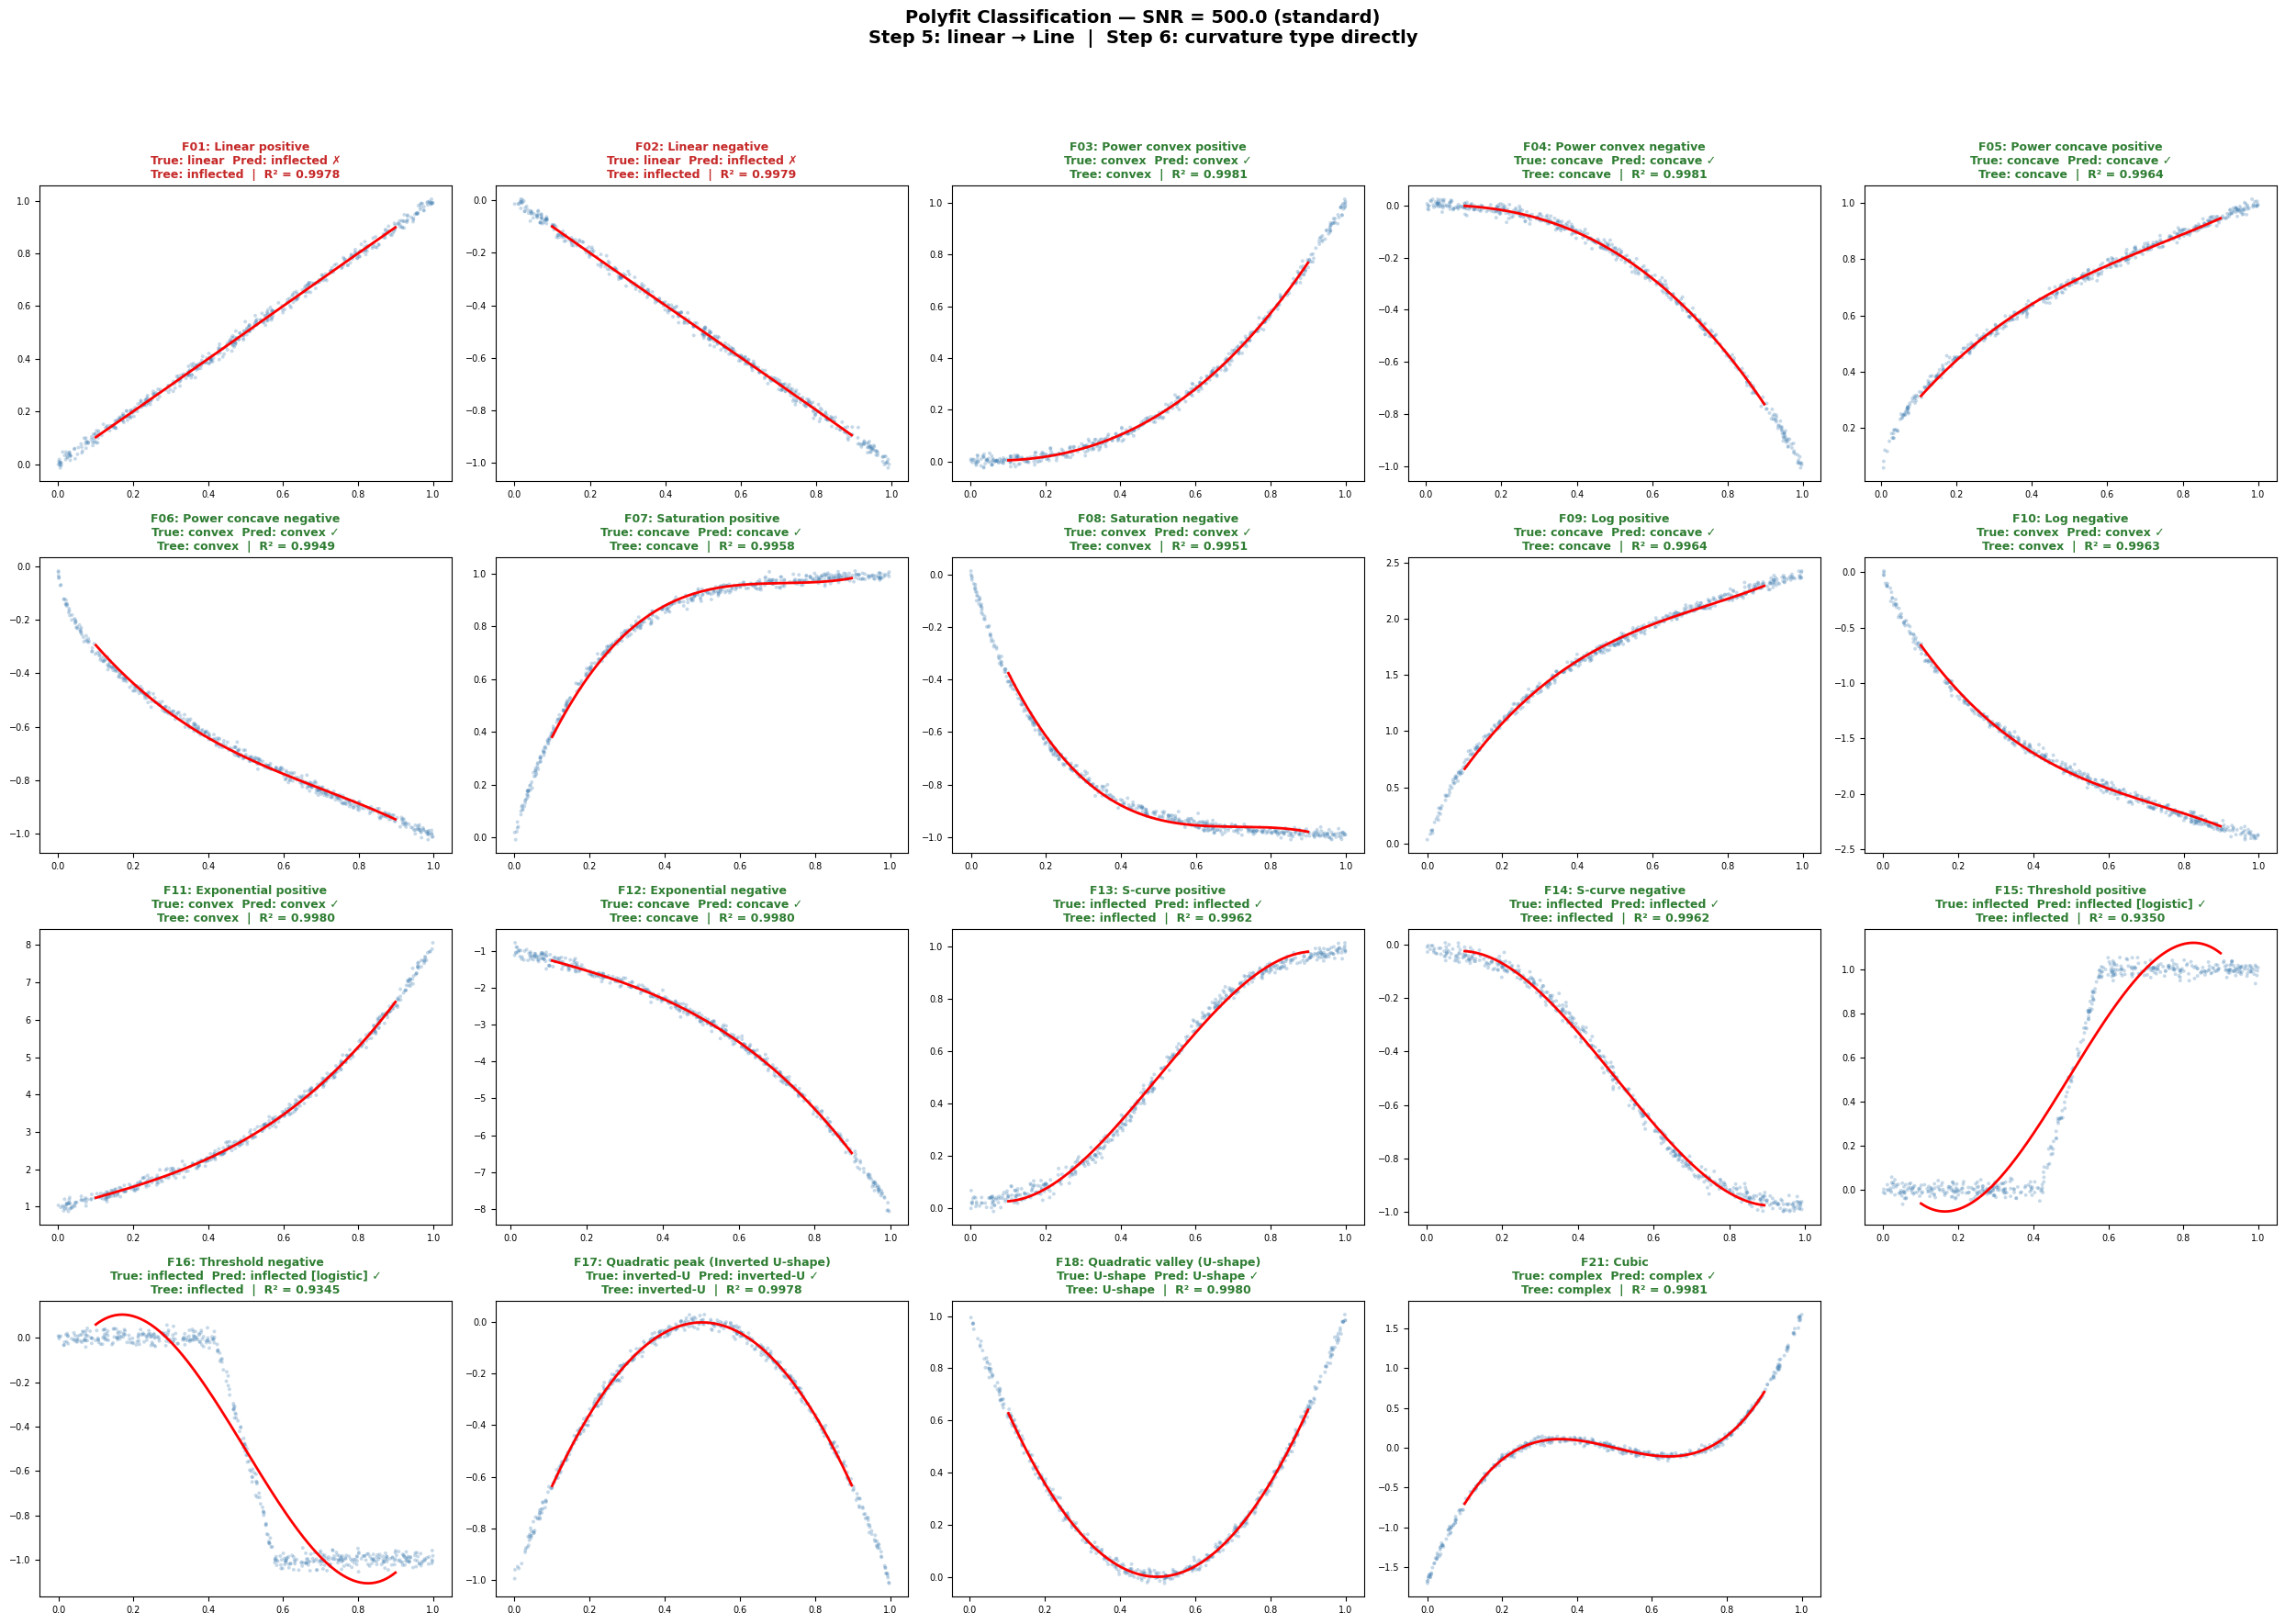

In [29]:
rep0 = val_df[val_df['replicate'] == 0]
n_fam = len(TARGET_FIDS)
ncols = 5
nrows = math.ceil(n_fam / ncols)

SHAPE_COLORS = {
    'linear': '#26C6DA', 'convex': '#E53935', 'concave': '#1E88E5',
    'inflected': '#43A047', 'U-shape': '#8E24AA',
    'inverted-U': '#D81B60', 'complex': '#546E7A',
}

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes_flat = axes.flatten()

for i, fid in enumerate(TARGET_FIDS):
    ax = axes_flat[i]
    row = val_cases[(val_cases['family_id'] == fid) &
                    (val_cases['replicate'] == 0)].iloc[0]
    idx = case_idx_map[row['case_id']]
    x, y = x_all[idx], y_all[idx]
    res_row = rep0[rep0['family_id'] == fid].iloc[0]

    ax.scatter(x, y, s=8, alpha=0.3, color='steelblue', edgecolors='none')
    ax.plot(res_row['x_grid'], res_row['f_grid'], color='red', lw=2)

    ok = res_row['correct']
    mark = '✓' if ok else '✗'
    clr = '#2E7D32' if ok else '#C62828'
    fallback = ' [logistic]' if res_row['logistic_used'] else ''

    tree_label = 'Line' if res_row['shape'] == 'linear' else res_row['shape']
    ax.set_title(
        f'{fid}: {SHORT[fid]}\n'
        f'True: {GROUND_TRUTH[fid]}  Pred: {res_row["shape"]}{fallback} {mark}\n'
        f'Tree: {tree_label}  |  R² = {res_row["r2_3"]:.4f}',
        fontsize=9, color=clr, fontweight='bold')
    ax.tick_params(labelsize=7)

for j in range(n_fam, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(f'Polyfit Classification — SNR = {VAL_SNR} (standard)\n'
             f'Step 5: linear → Line  |  Step 6: curvature type directly',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(OUT_DIR / 'clean_validation.png', dpi=150, bbox_inches='tight')
plt.show()

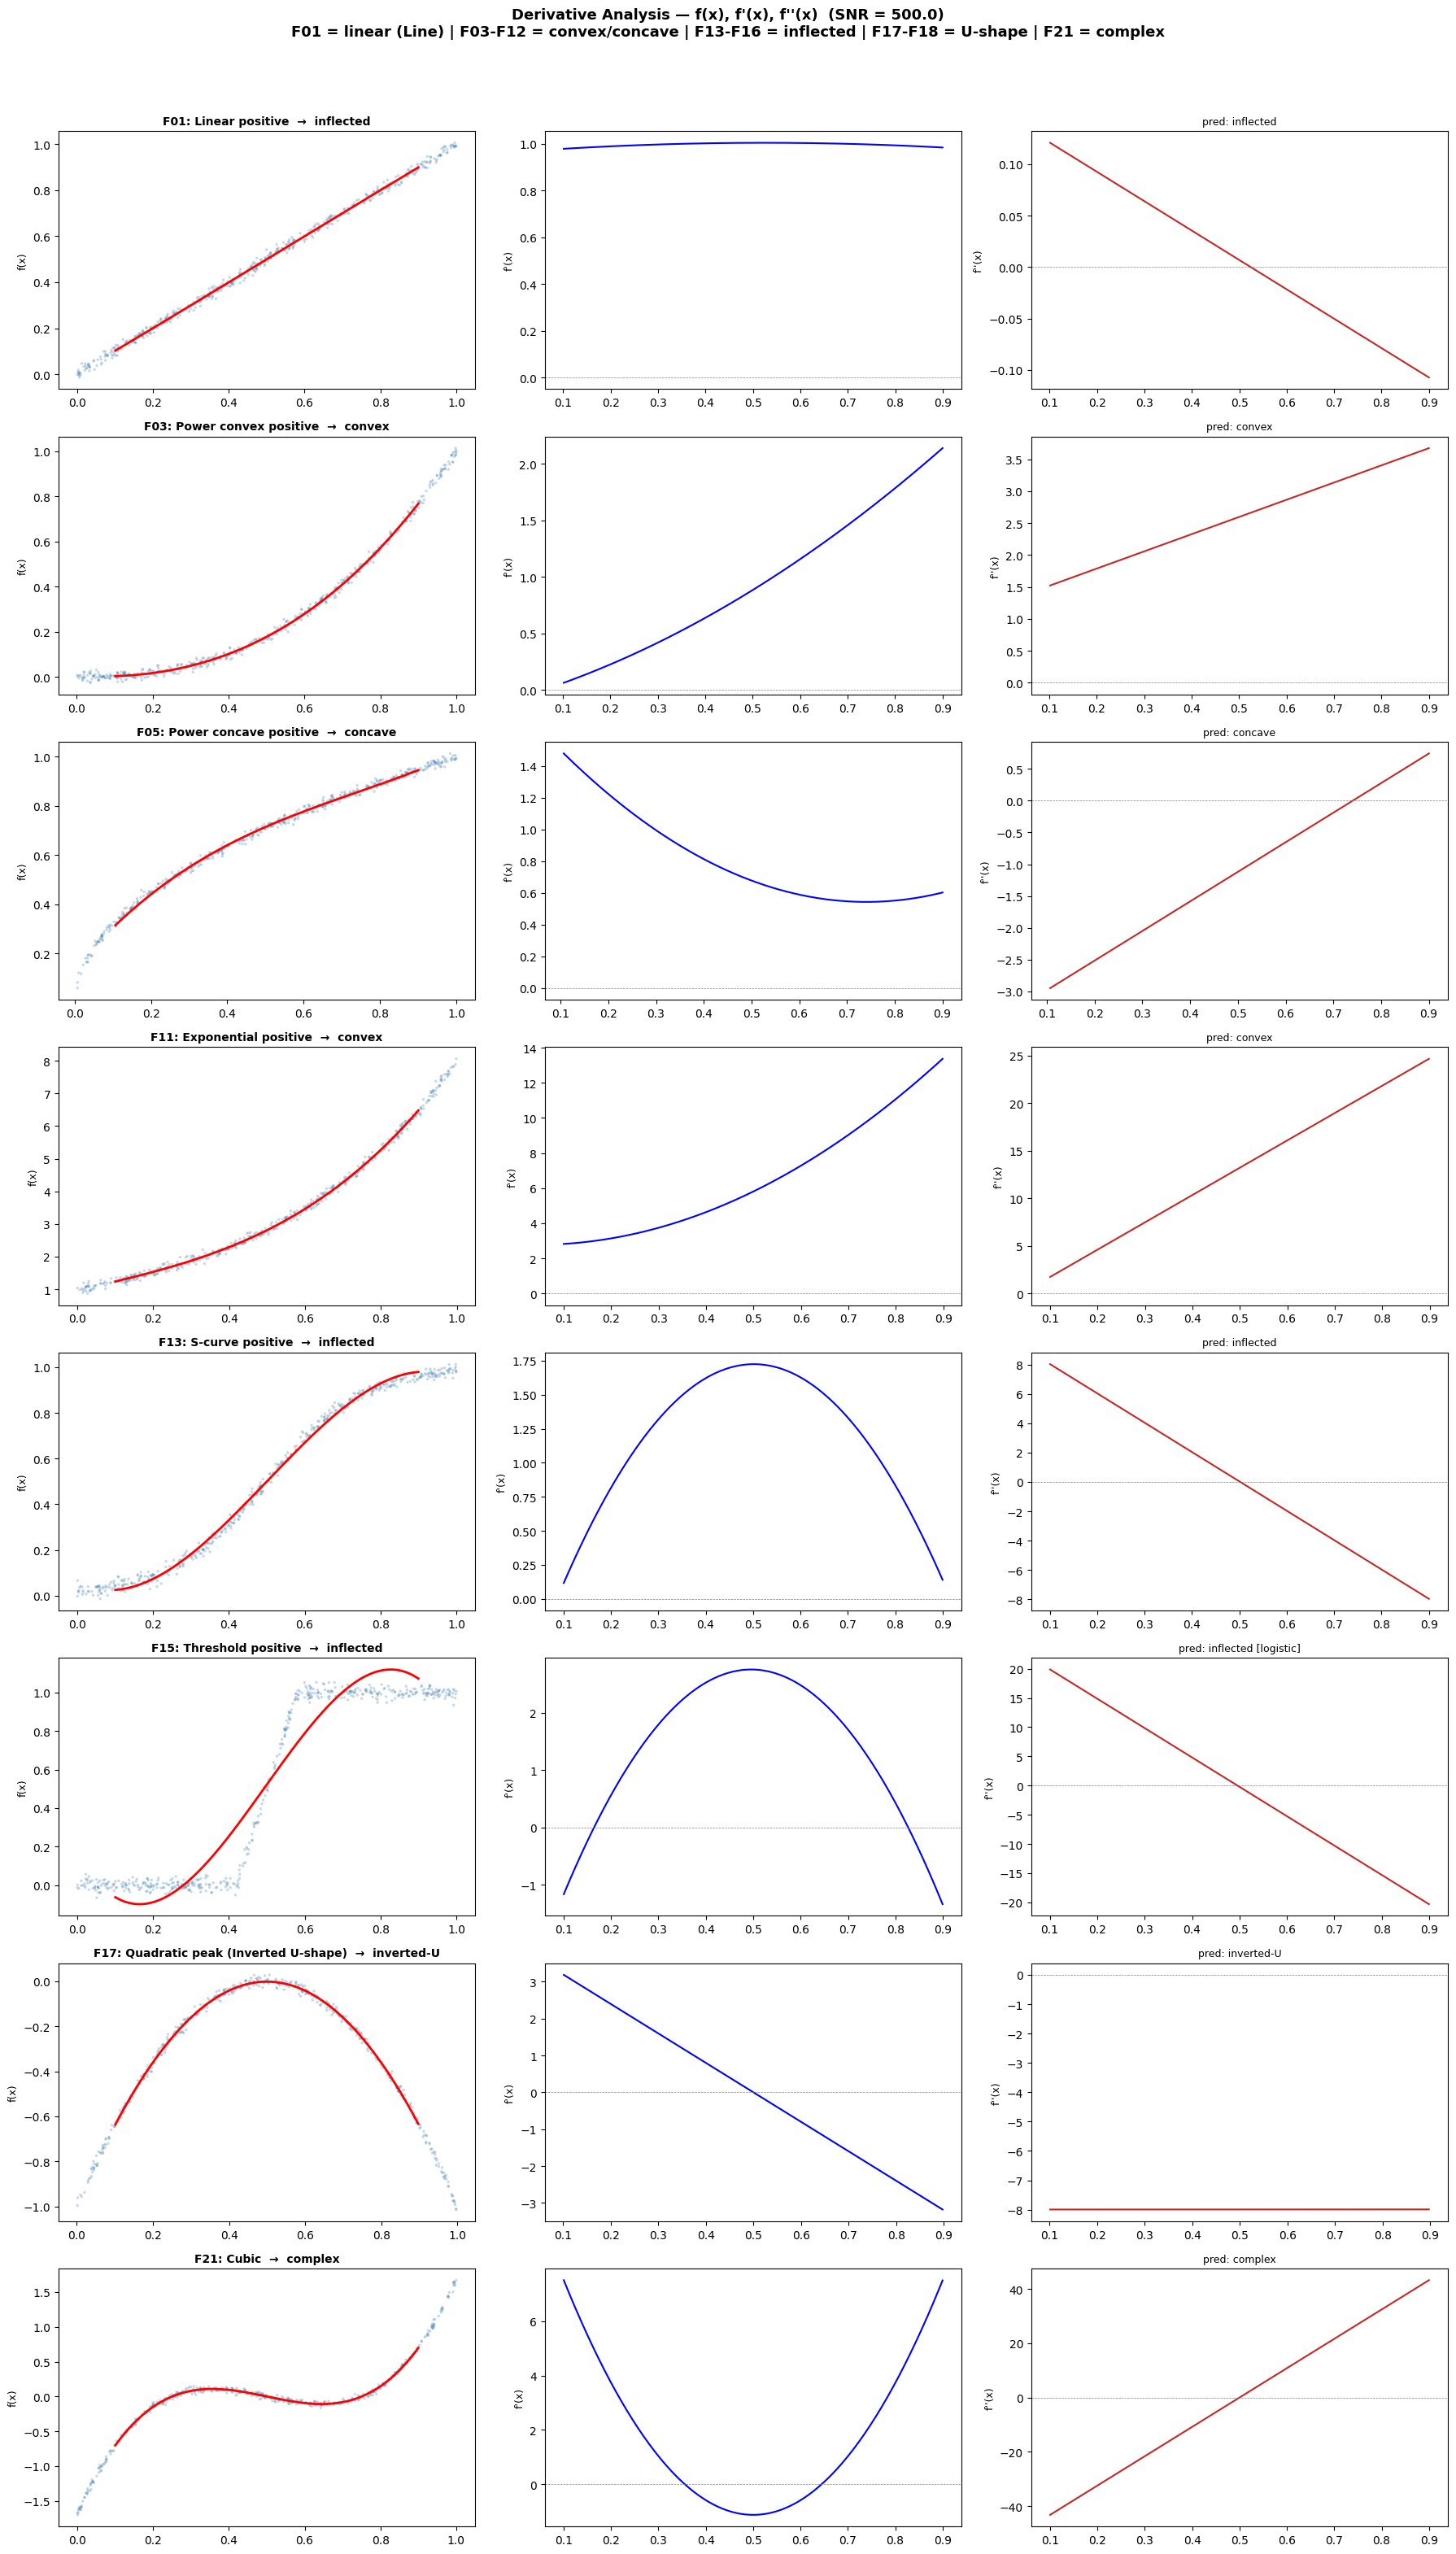

In [30]:
show_fids = ['F01', 'F03', 'F05', 'F11', 'F13', 'F15', 'F17', 'F21']

fig, axes = plt.subplots(len(show_fids), 3, figsize=(18, 4 * len(show_fids)))

for ri, fid in enumerate(show_fids):
    r = rep0[rep0['family_id'] == fid].iloc[0]
    idx = case_idx_map[val_cases[(val_cases['family_id'] == fid) &
                                  (val_cases['replicate'] == 0)].iloc[0]['case_id']]
    x, y = x_all[idx], y_all[idx]

    axes[ri, 0].scatter(x, y, s=6, alpha=0.3, color='steelblue', edgecolors='none')
    axes[ri, 0].plot(r['x_grid'], r['f_grid'], 'r-', lw=2)
    axes[ri, 0].set_ylabel('f(x)', fontsize=9)
    tree_label = 'Line' if r['shape'] == 'linear' else r['shape']
    axes[ri, 0].set_title(f'{fid}: {SHORT[fid]}  →  {tree_label}', fontsize=10, fontweight='bold')

    axes[ri, 1].plot(r['x_grid'], r['f1_grid'], 'b-', lw=1.5)
    axes[ri, 1].axhline(0, color='gray', lw=0.5, ls='--')
    axes[ri, 1].set_ylabel("f'(x)", fontsize=9)

    axes[ri, 2].plot(r['x_grid'], r['f2_grid'], color='#C62828', lw=1.5)
    axes[ri, 2].axhline(0, color='gray', lw=0.5, ls='--')
    axes[ri, 2].set_ylabel("f''(x)", fontsize=9)
    fallback = ' [logistic]' if r['logistic_used'] else ''
    axes[ri, 2].set_title(f'pred: {r["shape"]}{fallback}', fontsize=9)

fig.suptitle(f"Derivative Analysis — f(x), f'(x), f''(x)  (SNR = {VAL_SNR})\n"
             f"F01 = linear (Line) | F03-F12 = convex/concave | F13-F16 = inflected | F17-F18 = U-shape | F21 = complex",
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUT_DIR / 'derivative_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Noise Degradation Analysis

Run classification on **standard variant**, all SNR levels, all 10 replicates.
Show how accuracy and R² degrade with increasing noise.

In [31]:
noise_cases = target_cases[target_cases['variant_level'] == 'standard'].copy()
print(f'Running polyfit on {len(noise_cases):,} cases ...')
t0 = time.time()

noise_rows = []
for i, (_, row) in enumerate(noise_cases.iterrows()):
    idx = case_idx_map[row['case_id']]
    res = polyfit_classify(x_all[idx], y_all[idx])
    noise_rows.append({
        'case_id': row['case_id'],
        'family_id': row['family_id'],
        'snr': row['snr_float'],
        'replicate': row['replicate'],
        'pred_shape': res['shape'],
        'pred_dir': res['direction'],
        'r2_3': res['r2_3'],
        'r2_1': res['r2_1'],
        'logistic_used': res['logistic_used'],
    })
    if (i + 1) % 5000 == 0:
        elapsed = time.time() - t0
        rate = (i + 1) / elapsed
        eta = (len(noise_cases) - i - 1) / rate
        print(f'  {i+1:>6,}/{len(noise_cases):,}  ({elapsed:.0f}s elapsed, ~{eta:.0f}s remaining)')

noise_df = pd.DataFrame(noise_rows)
noise_df['true_shape'] = noise_df['family_id'].map(GROUND_TRUTH)
noise_df['correct'] = noise_df['pred_shape'] == noise_df['true_shape']

# Step 5: Line detection
noise_df['pred_line'] = noise_df['pred_shape'] == 'linear'
noise_df['true_line'] = noise_df['family_id'].map(TREE_STEP5) == 'Line'
noise_df['step5_correct'] = noise_df['pred_line'] == noise_df['true_line']

# Step 6: Curvature type (non-line only)
noise_nonline = noise_df[~noise_df['true_line']].copy()
noise_nonline['step6_correct'] = noise_nonline['pred_shape'] == noise_nonline['true_shape']

elapsed = time.time() - t0
n_logistic = noise_df['logistic_used'].sum()
print(f'Done in {elapsed:.0f}s')
print(f'Logistic fallback triggered: {n_logistic} / {len(noise_df)} ({n_logistic/len(noise_df):.1%})')
print(f'\nOverall shape accuracy: {noise_df["correct"].mean():.1%}')
print(f'Step 5 (Line detection) accuracy: {noise_df["step5_correct"].mean():.1%}')
print(f'Step 6 (Curvature type) accuracy: {noise_nonline["step6_correct"].mean():.1%}')

noise_df.to_csv(OUT_DIR / 'noise_classification.csv', index=False)

Running polyfit on 38,190 cases ...
   5,000/38,190  (27s elapsed, ~181s remaining)
  10,000/38,190  (45s elapsed, ~128s remaining)
  15,000/38,190  (79s elapsed, ~122s remaining)
  20,000/38,190  (100s elapsed, ~91s remaining)
  25,000/38,190  (131s elapsed, ~69s remaining)
  30,000/38,190  (159s elapsed, ~43s remaining)
  35,000/38,190  (191s elapsed, ~17s remaining)
Done in 274s
Logistic fallback triggered: 1424 / 38190 (3.7%)

Overall shape accuracy: 55.4%
Step 5 (Line detection) accuracy: 90.0%
Step 6 (Curvature type) accuracy: 61.4%


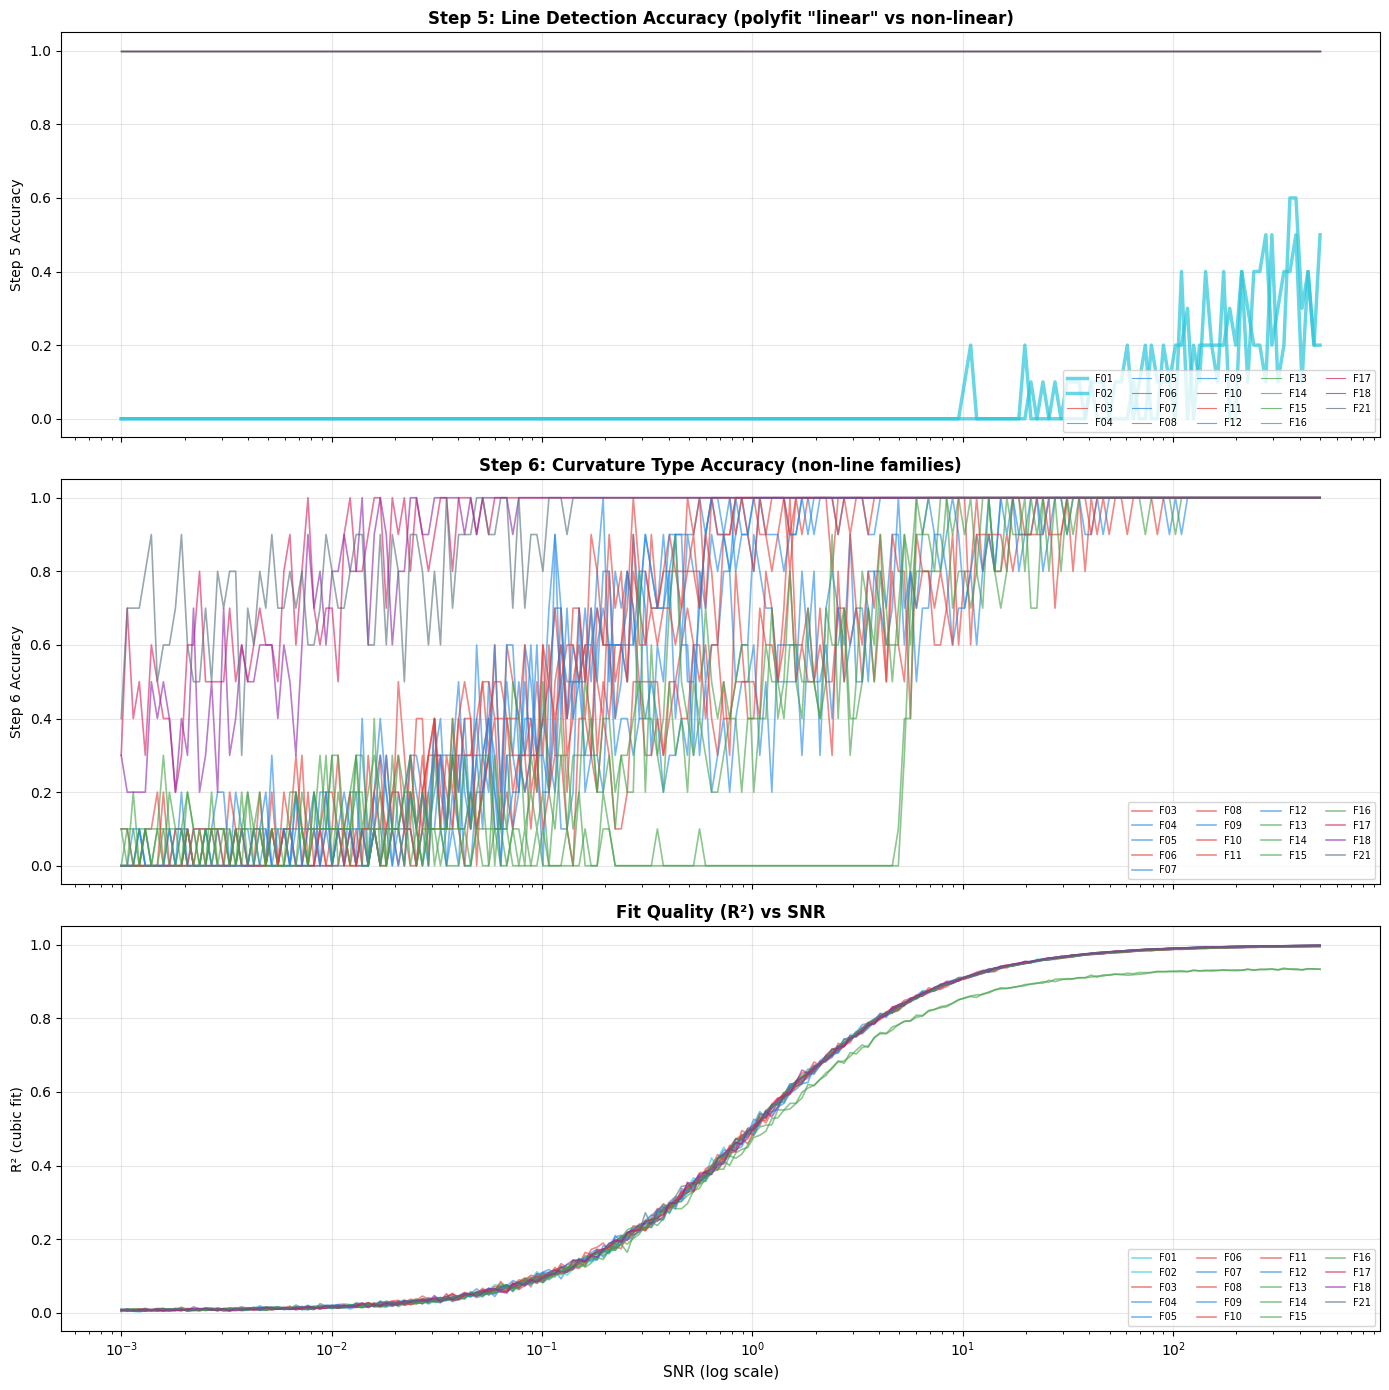

In [32]:
agg = noise_df.groupby(['family_id', 'snr']).agg(
    accuracy=('correct', 'mean'),
    step5_acc=('step5_correct', 'mean'),
    r2_mean=('r2_3', 'mean'),
).reset_index()

agg_nonline = noise_nonline.groupby(['family_id', 'snr']).agg(
    step6_acc=('step6_correct', 'mean'),
).reset_index()

SHAPE_COLORS = {
    'linear': '#26C6DA', 'convex': '#E53935', 'concave': '#1E88E5',
    'inflected': '#43A047', 'U-shape': '#8E24AA',
    'inverted-U': '#D81B60', 'complex': '#546E7A',
}

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

# Panel 1: Step 5 — Line detection accuracy
for fid in TARGET_FIDS:
    sub = agg[(agg['family_id'] == fid) & np.isfinite(agg['snr'])].sort_values('snr')
    c = SHAPE_COLORS.get(GROUND_TRUTH[fid], 'gray')
    ls = '-' if TREE_STEP5[fid] == 'Line' else '-'
    lw = 2.5 if TREE_STEP5[fid] == 'Line' else 0.8
    axes[0].plot(sub['snr'], sub['step5_acc'], color=c, alpha=0.7, lw=lw, label=fid)

axes[0].set_title('Step 5: Line Detection Accuracy (polyfit "linear" vs non-linear)',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Step 5 Accuracy')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(fontsize=7, ncol=5, loc='lower right')
axes[0].grid(True, alpha=0.3)

# Panel 2: Step 6 — Curvature type accuracy (non-line only)
for fid in [f for f in TARGET_FIDS if GROUND_TRUTH[f] != 'linear']:
    sub = agg_nonline[(agg_nonline['family_id'] == fid) & np.isfinite(agg_nonline['snr'])].sort_values('snr')
    c = SHAPE_COLORS.get(GROUND_TRUTH[fid], 'gray')
    axes[1].plot(sub['snr'], sub['step6_acc'], color=c, alpha=0.6, lw=1.2, label=fid)

axes[1].set_title('Step 6: Curvature Type Accuracy (non-line families)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Step 6 Accuracy')
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(fontsize=7, ncol=4, loc='lower right')
axes[1].grid(True, alpha=0.3)

# Panel 3: R² vs SNR
for fid in TARGET_FIDS:
    sub = agg[(agg['family_id'] == fid) & np.isfinite(agg['snr'])].sort_values('snr')
    c = SHAPE_COLORS.get(GROUND_TRUTH[fid], 'gray')
    axes[2].plot(sub['snr'], sub['r2_mean'], color=c, alpha=0.6, lw=1.2, label=fid)

axes[2].set_title('Fit Quality (R²) vs SNR', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² (cubic fit)')
axes[2].set_ylim(-0.05, 1.05)
axes[2].set_xlabel('SNR (log scale)', fontsize=11)
axes[2].legend(fontsize=7, ncol=4, loc='lower right')
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xscale('log')

plt.tight_layout()
plt.savefig(OUT_DIR / 'noise_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

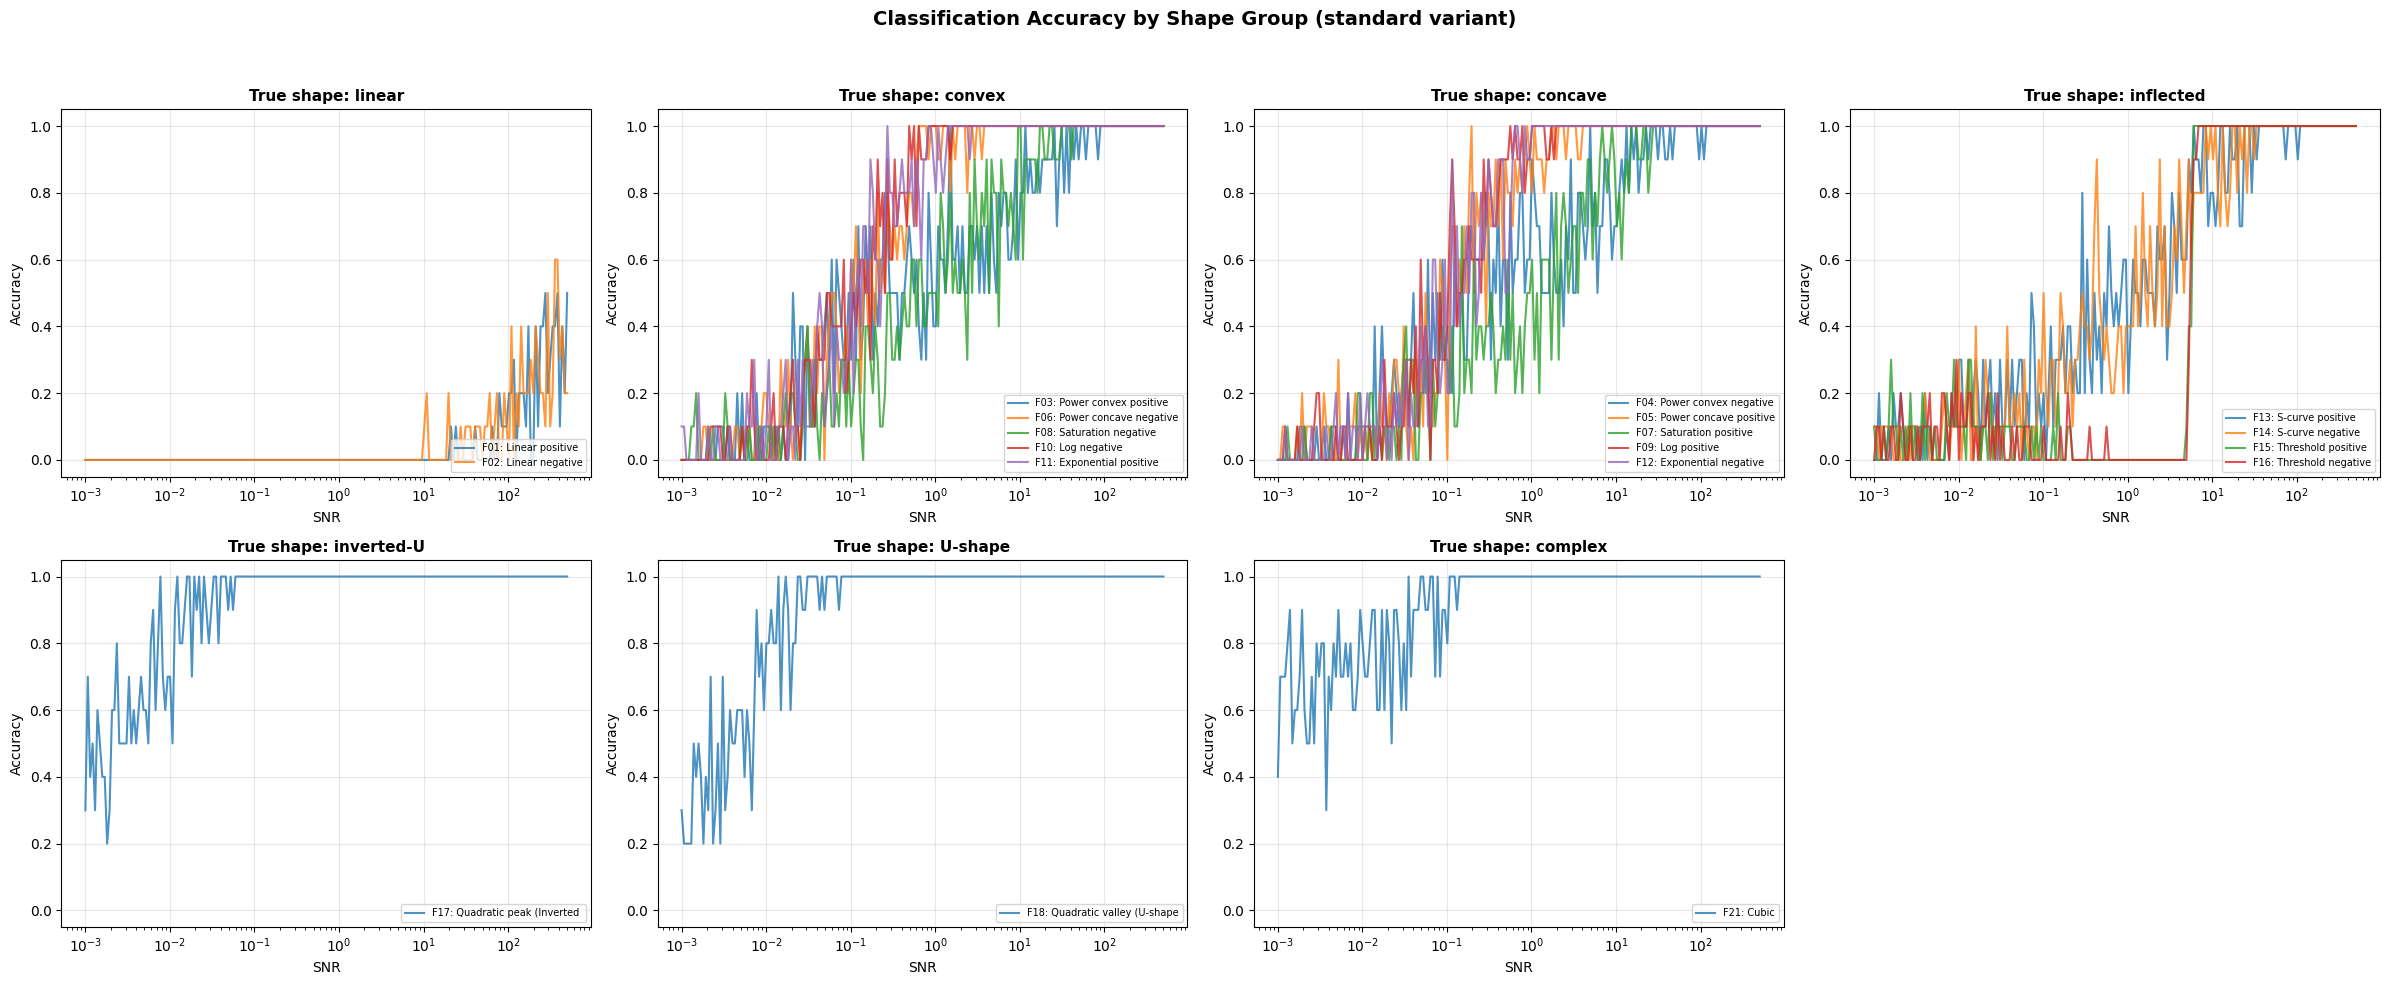

In [33]:
shape_groups = {}
for fid in TARGET_FIDS:
    shape_groups.setdefault(GROUND_TRUTH[fid], []).append(fid)

n_groups = len(shape_groups)
ncols = min(4, n_groups)
nrows = math.ceil(n_groups / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for gi, (shape_name, fids) in enumerate(shape_groups.items()):
    ax = axes_flat[gi]
    for fid in fids:
        sub = agg[(agg['family_id'] == fid) & np.isfinite(agg['snr'])].sort_values('snr')
        ax.plot(sub['snr'], sub['accuracy'], lw=1.5, alpha=0.8,
                label=f'{fid}: {SHORT[fid][:25]}')
    ax.set_xscale('log')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('SNR')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'True shape: {shape_name}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)

for j in range(n_groups, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Classification Accuracy by Shape Group (standard variant)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(OUT_DIR / 'accuracy_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Fuzzy Calibration

Use the relationship between **R²** and **classification accuracy** to define fuzzy membership zones.
R² is a natural calibration metric: when R² is high, classification is reliable; when low, it is not.

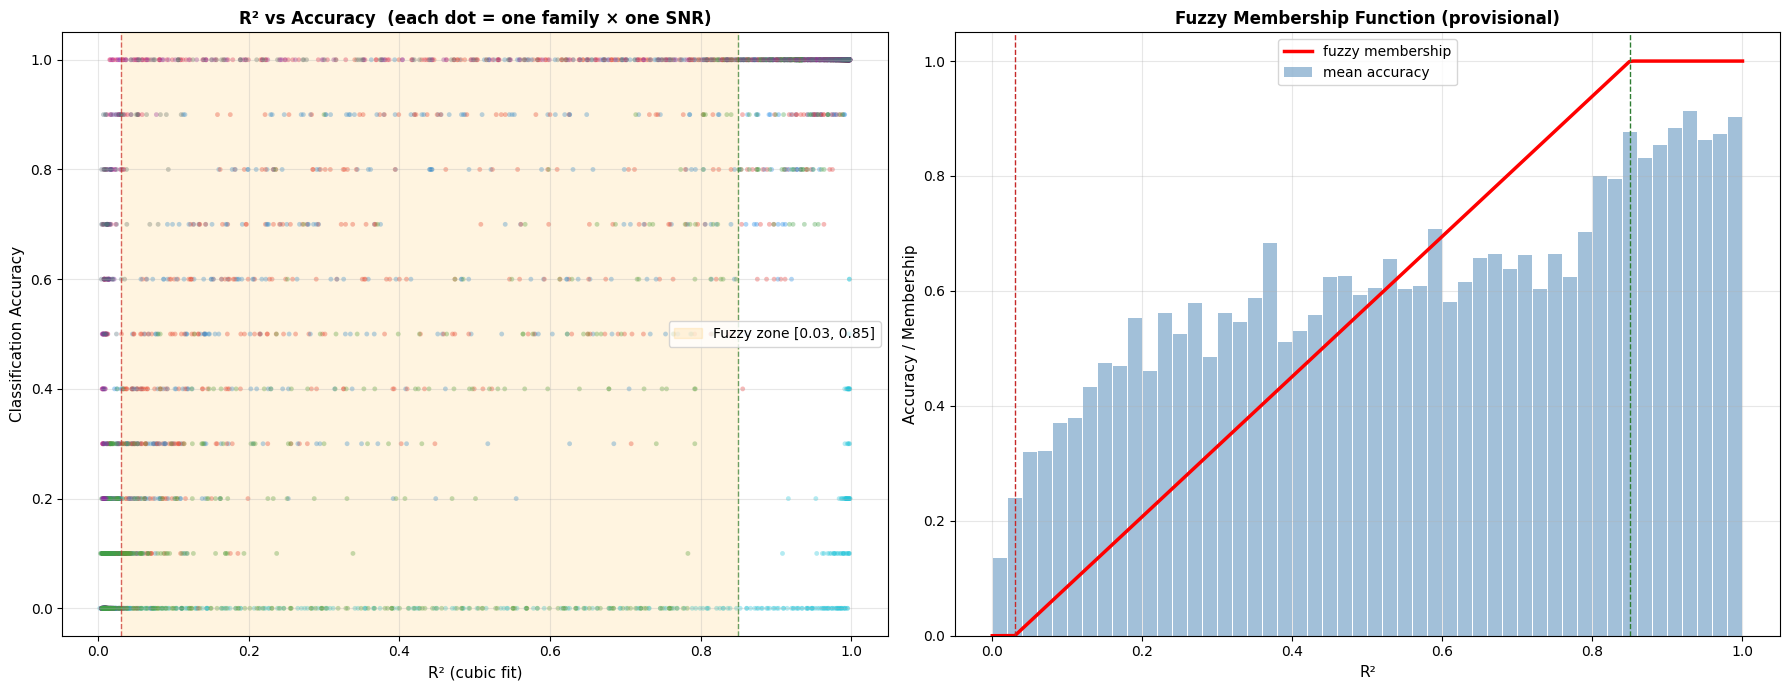

Provisional fuzzy zone:  R² ∈ [0.03, 0.85]
  R² > 0.85  →  confidence = 1.0  (clear detection)
  R² < 0.03  →  confidence = 0.0  (no detection)
  R² in [0.03, 0.85]  →  confidence varies (fuzzy)


In [34]:
def fuzzy_membership(value, lower, upper):
    if value >= upper:
        return 1.0
    elif value <= lower:
        return 0.0
    else:
        return (value - lower) / (upper - lower)


agg_finite = agg[np.isfinite(agg['snr'])].copy()

# Bin R2 and compute mean accuracy per bin
r2_edges = np.linspace(0, 1, 51)
bin_records = []
for lo, hi in zip(r2_edges[:-1], r2_edges[1:]):
    mask = (agg_finite['r2_mean'] >= lo) & (agg_finite['r2_mean'] < hi)
    if mask.sum() > 0:
        bin_records.append({'r2_mid': (lo + hi) / 2, 'mean_acc': agg_finite.loc[mask, 'accuracy'].mean(), 'n': int(mask.sum())})

bin_df = pd.DataFrame(bin_records)

below = bin_df[bin_df['mean_acc'] < 0.3]
above = bin_df[bin_df['mean_acc'] > 0.8]
FUZZY_LO = float(below['r2_mid'].max()) if len(below) > 0 else 0.0
FUZZY_HI = float(above['r2_mid'].min()) if len(above) > 0 else 1.0

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: R2 vs accuracy scatter
ax = axes[0]
for fid in TARGET_FIDS:
    sub = agg_finite[agg_finite['family_id'] == fid]
    c = SHAPE_COLORS.get(GROUND_TRUTH[fid], 'gray')
    ax.scatter(sub['r2_mean'], sub['accuracy'], s=12, alpha=0.35, color=c, edgecolors='none')

ax.axvspan(FUZZY_LO, FUZZY_HI, alpha=0.12, color='orange',
           label=f'Fuzzy zone [{FUZZY_LO:.2f}, {FUZZY_HI:.2f}]')
ax.axvline(FUZZY_LO, color='#C62828', ls='--', lw=1, alpha=0.7)
ax.axvline(FUZZY_HI, color='#2E7D32', ls='--', lw=1, alpha=0.7)
ax.set_xlabel('R\u00b2 (cubic fit)', fontsize=11)
ax.set_ylabel('Classification Accuracy', fontsize=11)
ax.set_title('R\u00b2 vs Accuracy  (each dot = one family \u00d7 one SNR)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: binned accuracy curve + fuzzy membership
ax2 = axes[1]
ax2.bar(bin_df['r2_mid'], bin_df['mean_acc'], width=0.018, alpha=0.5, color='steelblue', label='mean accuracy')
r2_line = np.linspace(0, 1, 200)
mem_line = [fuzzy_membership(r, FUZZY_LO, FUZZY_HI) for r in r2_line]
ax2.plot(r2_line, mem_line, 'r-', lw=2.5, label='fuzzy membership')
ax2.axvline(FUZZY_LO, color='#C62828', ls='--', lw=1)
ax2.axvline(FUZZY_HI, color='#2E7D32', ls='--', lw=1)
ax2.set_xlabel('R\u00b2', fontsize=11)
ax2.set_ylabel('Accuracy / Membership', fontsize=11)
ax2.set_title('Fuzzy Membership Function (provisional)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fuzzy_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Provisional fuzzy zone:  R\u00b2 \u2208 [{FUZZY_LO:.2f}, {FUZZY_HI:.2f}]')
print(f'  R\u00b2 > {FUZZY_HI:.2f}  \u2192  confidence = 1.0  (clear detection)')
print(f'  R\u00b2 < {FUZZY_LO:.2f}  \u2192  confidence = 0.0  (no detection)')
print(f'  R\u00b2 in [{FUZZY_LO:.2f}, {FUZZY_HI:.2f}]  \u2192  confidence varies (fuzzy)')

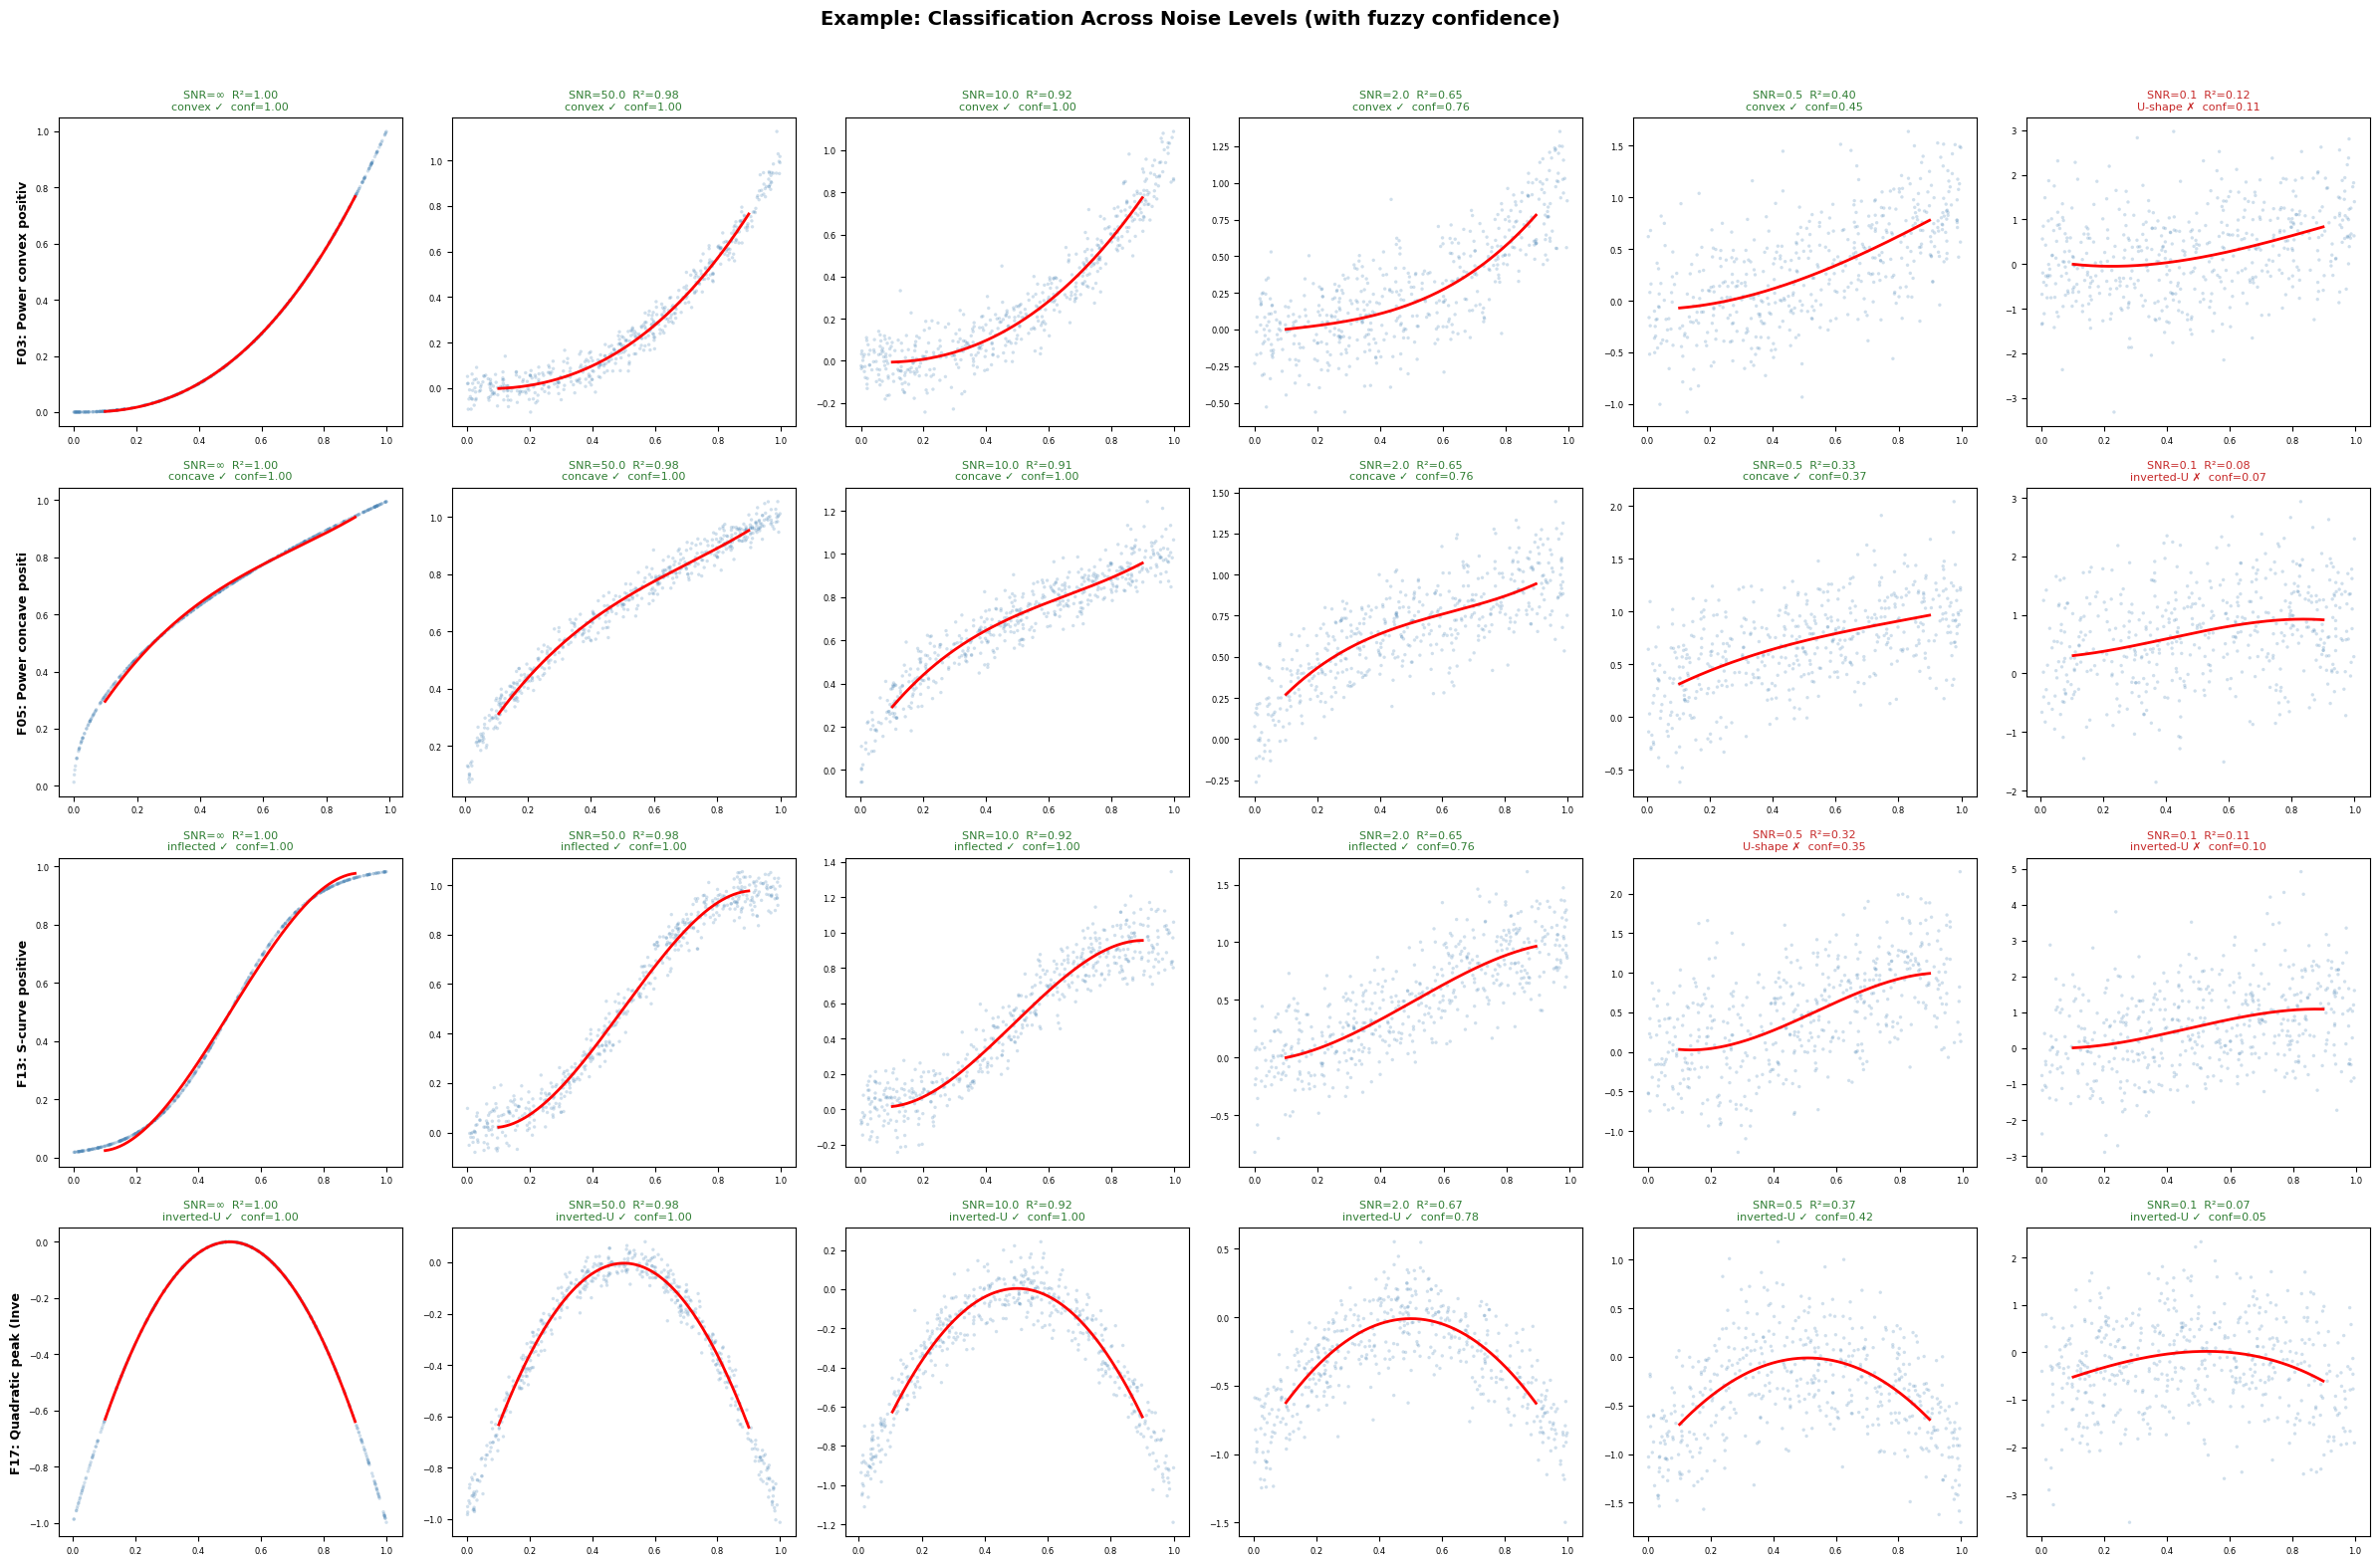

In [35]:
example_fids = ['F03', 'F05', 'F13', 'F17']
snr_picks = [np.inf, 50.0, 10.0, 2.0, 0.5, 0.1]

fig, axes = plt.subplots(len(example_fids), len(snr_picks),
                         figsize=(4 * len(snr_picks), 4 * len(example_fids)))

for ri, fid in enumerate(example_fids):
    fam_cases = noise_cases[
        (noise_cases['family_id'] == fid) &
        (noise_cases['replicate'] == 0)
    ].copy()

    for ci, snr_val in enumerate(snr_picks):
        ax = axes[ri, ci]

        if np.isinf(snr_val):
            match = fam_cases[fam_cases['snr_float'] == np.inf]
        else:
            fam_cases['_d'] = (fam_cases['snr_float'] - snr_val).abs()
            match = fam_cases.nsmallest(1, '_d')

        if len(match) > 0:
            cid = match.iloc[0]['case_id']
            idx = case_idx_map[cid]
            x, y = x_all[idx], y_all[idx]
            res = polyfit_classify(x, y)
            conf = fuzzy_membership(res['r2_3'], FUZZY_LO, FUZZY_HI)

            ax.scatter(x, y, s=6, alpha=0.25, color='steelblue', edgecolors='none')
            ax.plot(res['x_grid'], res['f_grid'], 'r-', lw=2)

            snr_lbl = '\u221e' if np.isinf(snr_val) else f'{snr_val:.1f}'
            ok = res['shape'] == GROUND_TRUTH[fid]
            mark = '\u2713' if ok else '\u2717'
            ax.set_title(f'SNR={snr_lbl}  R\u00b2={res["r2_3"]:.2f}\n'
                         f'{res["shape"]} {mark}  conf={conf:.2f}',
                         fontsize=8, color='#2E7D32' if ok else '#C62828')

        ax.tick_params(labelsize=6)
        if ci == 0:
            ax.set_ylabel(f'{fid}: {SHORT[fid][:20]}', fontsize=9, fontweight='bold')

fig.suptitle('Example: Classification Across Noise Levels (with fuzzy confidence)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUT_DIR / 'example_noise_levels.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# For each family: at each SNR, what fraction is correct / uncertain / wrong?
# Pick representative SNR levels for a readable table
snr_table_vals = [np.inf, 100, 50, 20, 10, 5, 2, 1, 0.5, 0.1]

rows = []
for fid in TARGET_FIDS:
    fam = noise_df[noise_df['family_id'] == fid]
    for snr_t in snr_table_vals:
        if np.isinf(snr_t):
            sub = fam[fam['snr'] == np.inf]
        else:
            closest = fam['snr'].unique()
            closest = closest[np.isfinite(closest)]
            actual = closest[np.argmin(np.abs(closest - snr_t))]
            sub = fam[fam['snr'] == actual]

        if len(sub) == 0:
            continue

        acc = sub['correct'].mean()
        r2m = sub['r2_3'].mean()
        conf = fuzzy_membership(r2m, FUZZY_LO, FUZZY_HI)
        pred_mode = sub['pred_shape'].mode().iloc[0]
        rows.append({
            'family_id': fid,
            'snr': '\u221e' if np.isinf(snr_t) else snr_t,
            'accuracy': f'{acc:.0%}',
            'R2': f'{r2m:.3f}',
            'confidence': f'{conf:.2f}',
            'pred_mode': pred_mode,
        })

result_table = pd.DataFrame(rows)
pivot = result_table.pivot_table(index='family_id', columns='snr',
                                 values='accuracy', aggfunc='first')
print('Classification accuracy by family and SNR level:')
display(pivot)

Classification accuracy by family and SNR level:


snr,0.1,0.5,1,2,5,10,20,50,100,∞
family_id,,,,,,,,,,
F01,0%,0%,0%,0%,0%,0%,0%,0%,20%,100%
F02,0%,0%,0%,0%,0%,10%,20%,0%,0%,100%
F03,30%,70%,40%,50%,60%,80%,90%,90%,100%,100%
F04,40%,60%,90%,50%,100%,70%,90%,100%,100%,100%
F05,0%,90%,80%,90%,100%,100%,100%,100%,100%,100%
F06,60%,80%,100%,100%,100%,100%,100%,100%,100%,100%
F07,30%,30%,60%,80%,90%,70%,90%,100%,100%,100%
F08,10%,40%,50%,50%,80%,100%,90%,100%,100%,100%
F09,40%,90%,100%,100%,100%,100%,100%,100%,100%,100%


## Summary

**Method**: Global cubic polynomial fit → classify from f′(x) and f″(x) derivative patterns.

**Tree integration**:
- **Step 5 (Line Detection)**: polyfit `'linear'` replaces slope SD < 0.1
  - f″ negligible relative to f′ → Line
  - F01/F02 correctly detected as linear
- **Step 6 (Curvature Type)**: polyfit shape directly replaces V_s gate + slope pattern
  - No "uncertain" layer — every non-line case gets classified
  - convex / concave / inflected / U-shape / inverted-U / complex
  - Logistic fallback handles F15/F16 (threshold → inflected)

**Advantages over segment-based approach**:
1. Line detection from derivative analysis, not arbitrary slope SD threshold
2. Curvature classification from continuous f″(x), not discrete E/M/L slope ordering
3. No V_s gate → no "Weak/Uncertain" cases left unclassified
4. R² provides natural fuzzy confidence metric